# Tablero de Proyección Chain Ladder — Análisis Vintage OC

Proyección del triángulo vintage usando el método **Chain Ladder** (factores de desarrollo promedio ponderados por volumen).

**Pasos:**
1. Ejecutar proyección Chain Ladder
2. Revisar factores promedio
3. Visualizar matriz proyectada
4. Curvas observadas vs proyectadas
5. Tabla de mora última (ultimate)
6. Comparación de ultimates por año

---
## 0. Setup

In [17]:
import os
import subprocess
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from matplotlib.lines import Line2D

# Configurar rutas
PROJECT_ROOT = os.path.dirname(os.getcwd()) if os.path.basename(os.getcwd()) == "notebooks" else os.getcwd()
SRC_DIR = os.path.join(PROJECT_ROOT, "src")
PROCESSED_DIR = os.path.join(PROJECT_ROOT, "data", "processed")

# ---------------------------------------------------------------------------
# PARÁMETROS CONFIGURABLES
# ---------------------------------------------------------------------------
MOB_OBJETIVO = 18
N_DESTACAR = 5
COLOR_2024 = "#2171b5"
COLOR_2025 = "#e6550d"
COLOR_2026 = "#888888"
ALPHA_INDIVIDUAL = 0.18
ALPHA_HIGHLIGHT = 0.85

print(f"Raíz del proyecto: {PROJECT_ROOT}")
print(f"MOB objetivo: {MOB_OBJETIVO}")
print(f"Cohortes a resaltar: últimas {N_DESTACAR}")

Raíz del proyecto: d:\Python\Vintage Saldo (moroso-vencido)
MOB objetivo: 18
Cohortes a resaltar: últimas 5


---
## 1. Ejecutar proyección Chain Ladder

In [18]:
result = subprocess.run(
    ["py", os.path.join(SRC_DIR, "generar_proyeccion_chainladder.py")],
    capture_output=True, text=True, cwd=PROJECT_ROOT
)
print(result.stdout)
if result.returncode != 0:
    print("ERROR:", result.stderr)

Proyeccion Chain Ladder
Matriz leida: 49 cohortes x 49 MOBs
MOB objetivo: 18

Factores Chain Ladder (17 transiciones):
  1->2: 1.008138
  2->3: 1.037634
  3->4: 1.074747
  4->5: 1.051816
  5->6: 1.067540
  6->7: 1.105888
  7->8: 1.023107
  8->9: 0.972854
  9->10: 0.963407
  10->11: 0.964443
  11->12: 0.965834
  12->13: 0.965404
  13->14: 0.969646
  14->15: 0.973952
  15->16: 0.975698
  16->17: 0.978149
  17->18: 0.981067

Factores guardados: d:\Python\Vintage Saldo (moroso-vencido)\data\processed\factores_chainladder.csv

Celdas observadas: 729
Celdas proyectadas: 153
Matriz proyectada guardada: d:\Python\Vintage Saldo (moroso-vencido)\data\processed\matriz_proyectada.csv
Marcadores guardados: d:\Python\Vintage Saldo (moroso-vencido)\data\processed\matriz_proyectada_marcadores.csv

DiagnÃ³stico de estabilidad de factores CL:
  TransiciÃ³n |   Factor |       CV | N cohortes | Estable?
  ---------- | -------- | -------- | ---------- | --------
        1->2 |   1.0081 |   0.099  |        

---
## 2. Factores Chain Ladder promedio

Factores de desarrollo promedio ponderados por volumen. Cada factor indica cuánto se multiplica el índice de morosidad al pasar de un MOB al siguiente.

- **Factor > 1**: la mora crece en esa transición
- **Factor < 1**: la mora baja
- **Factor = 1**: estable

Factores Chain Ladder promedio ponderados:

    1->2: 1.008138  ▲ crece
    2->3: 1.037634  ▲ crece
    3->4: 1.074747  ▲ crece
    4->5: 1.051816  ▲ crece
    5->6: 1.067540  ▲ crece
    6->7: 1.105888  ▲ crece
    7->8: 1.023107  ▲ crece
    8->9: 0.972854  ▼ baja
   9->10: 0.963407  ▼ baja
  10->11: 0.964443  ▼ baja
  11->12: 0.965834  ▼ baja
  12->13: 0.965404  ▼ baja
  13->14: 0.969646  ▼ baja
  14->15: 0.973952  ▼ baja
  15->16: 0.975698  ▼ baja
  16->17: 0.978149  ▼ baja
  17->18: 0.981067  ▼ baja


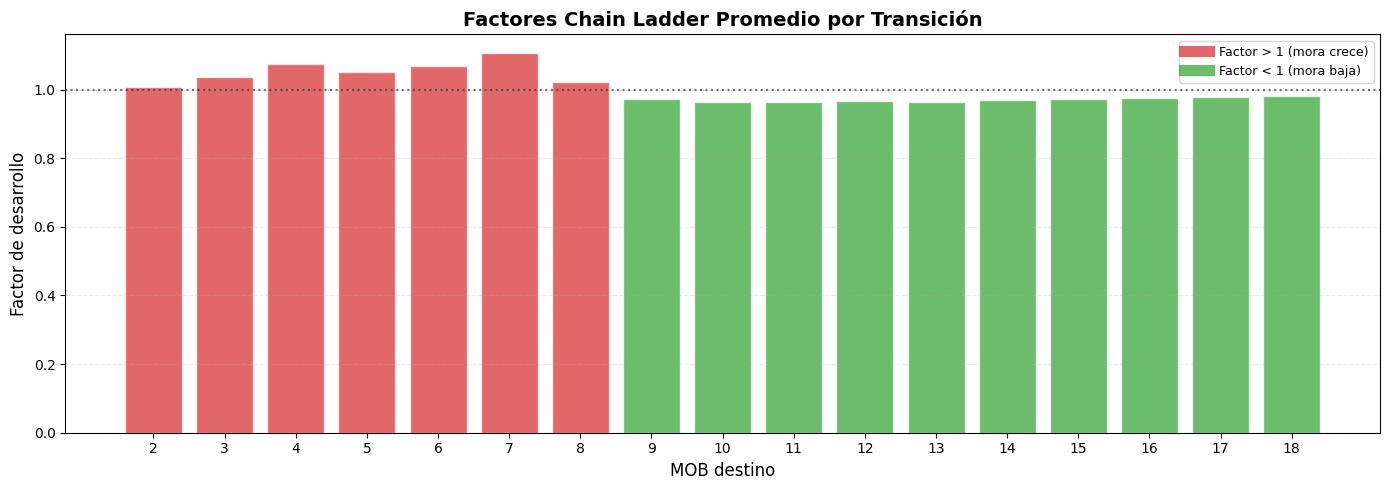

Gráfico guardado en reports/factores_chainladder.png


In [19]:
factores_cl = pd.read_csv(os.path.join(PROCESSED_DIR, "factores_chainladder.csv"), sep=";", decimal=",")

# Mostrar como tabla
print("Factores Chain Ladder promedio ponderados:\n")
for col in factores_cl.columns:
    val = factores_cl[col].iloc[0]
    zona = "▲ crece" if val > 1.0 else "▼ baja"
    print(f"  {col:>6s}: {val:.6f}  {zona}")

# Gráfico de factores
fig, ax = plt.subplots(figsize=(14, 5))
transiciones = factores_cl.columns.tolist()
valores = factores_cl.iloc[0].values
mob_destino = [int(t.split("->")[1]) for t in transiciones]

colores = ["#d62728" if v > 1 else "#2ca02c" for v in valores]
ax.bar(mob_destino, valores, color=colores, alpha=0.7, edgecolor="white")
ax.axhline(y=1.0, color="#333333", linewidth=1.5, linestyle=":", alpha=0.7)
ax.set_xlabel("MOB destino", fontsize=12)
ax.set_ylabel("Factor de desarrollo", fontsize=12)
ax.set_title("Factores Chain Ladder Promedio por Transición", fontsize=14, fontweight="bold")
ax.set_xticks(mob_destino)
ax.grid(True, alpha=0.25, linestyle="--", axis="y")

legend_elements = [
    Line2D([0], [0], color="#d62728", lw=8, alpha=0.7, label="Factor > 1 (mora crece)"),
    Line2D([0], [0], color="#2ca02c", lw=8, alpha=0.7, label="Factor < 1 (mora baja)"),
]
ax.legend(handles=legend_elements, fontsize=9, loc="upper right")

plt.tight_layout()
plt.savefig(os.path.join(PROJECT_ROOT, "reports", "factores_chainladder.png"), dpi=150, bbox_inches="tight")
plt.show()
print("Gráfico guardado en reports/factores_chainladder.png")

---
## 3. Matriz Proyectada

Valores observados en fondo blanco, valores **proyectados** en fondo gris.

In [20]:
matriz_proy = pd.read_csv(os.path.join(PROCESSED_DIR, "matriz_proyectada.csv"), sep=";", decimal=",", index_col=0)
marcadores = pd.read_csv(os.path.join(PROCESSED_DIR, "matriz_proyectada_marcadores.csv"), sep=";", index_col=0)

# Estilo: fondo gris para proyectados, gradiente rojo-verde para valores
def estilo_proyectado(df_style):
    styles = pd.DataFrame("", index=marcadores.index, columns=marcadores.columns)
    styles[marcadores == True] = "background-color: #f0f0f0; font-style: italic"
    return styles

matriz_proy.style.format("{:.2%}", na_rep="-").apply(estilo_proyectado, axis=None).background_gradient(
    cmap="RdYlGn_r", axis=None
)

,MOB_1,MOB_2,MOB_3,MOB_4,MOB_5,MOB_6,MOB_7,MOB_8,MOB_9,MOB_10,MOB_11,MOB_12,MOB_13,MOB_14,MOB_15,MOB_16,MOB_17,MOB_18
cohorte,,,,,,,,,,,,,,,,,,
2022-01,12.08%,11.58%,11.83%,12.94%,13.46%,13.11%,15.75%,15.32%,16.15%,15.48%,14.50%,13.75%,13.30%,12.64%,12.23%,11.78%,11.22%,10.79%
2022-02,11.61%,11.40%,11.81%,12.68%,12.55%,12.80%,12.82%,16.30%,15.87%,14.92%,14.13%,13.58%,12.81%,12.28%,11.84%,11.24%,10.75%,10.46%
2022-03,11.09%,11.43%,11.16%,11.64%,12.92%,13.00%,14.02%,16.17%,15.20%,14.43%,13.94%,13.17%,12.58%,12.10%,11.53%,10.99%,10.62%,10.35%
2022-04,12.15%,11.05%,10.34%,12.03%,12.65%,12.94%,15.33%,14.61%,15.03%,14.63%,13.84%,13.26%,12.68%,12.08%,11.46%,11.07%,10.76%,10.40%
2022-05,10.65%,9.48%,9.99%,11.29%,11.90%,12.31%,11.78%,14.30%,14.08%,13.25%,12.69%,12.11%,11.43%,10.86%,10.53%,10.22%,9.90%,9.54%
2022-06,9.17%,9.96%,9.93%,10.89%,11.82%,11.58%,12.30%,14.48%,13.83%,13.28%,12.80%,12.09%,11.37%,10.98%,10.64%,10.32%,9.90%,9.51%
2022-07,11.39%,10.46%,10.59%,11.64%,11.35%,11.36%,14.10%,13.72%,13.13%,12.60%,11.85%,11.10%,10.73%,10.33%,9.98%,9.55%,9.17%,8.91%
2022-08,10.13%,9.49%,9.71%,9.53%,9.96%,10.56%,12.53%,12.34%,11.90%,11.08%,10.28%,9.91%,9.51%,9.21%,8.79%,8.35%,8.10%,7.95%
2022-09,9.60%,9.38%,8.54%,9.11%,10.09%,10.27%,12.31%,11.91%,11.28%,10.42%,10.15%,9.69%,9.31%,8.83%,8.32%,8.06%,7.93%,7.69%


---
## 4. Curvas Vintage: Observado vs Proyectado

Líneas **sólidas** = datos observados. Líneas **punteadas** = proyección Chain Ladder.

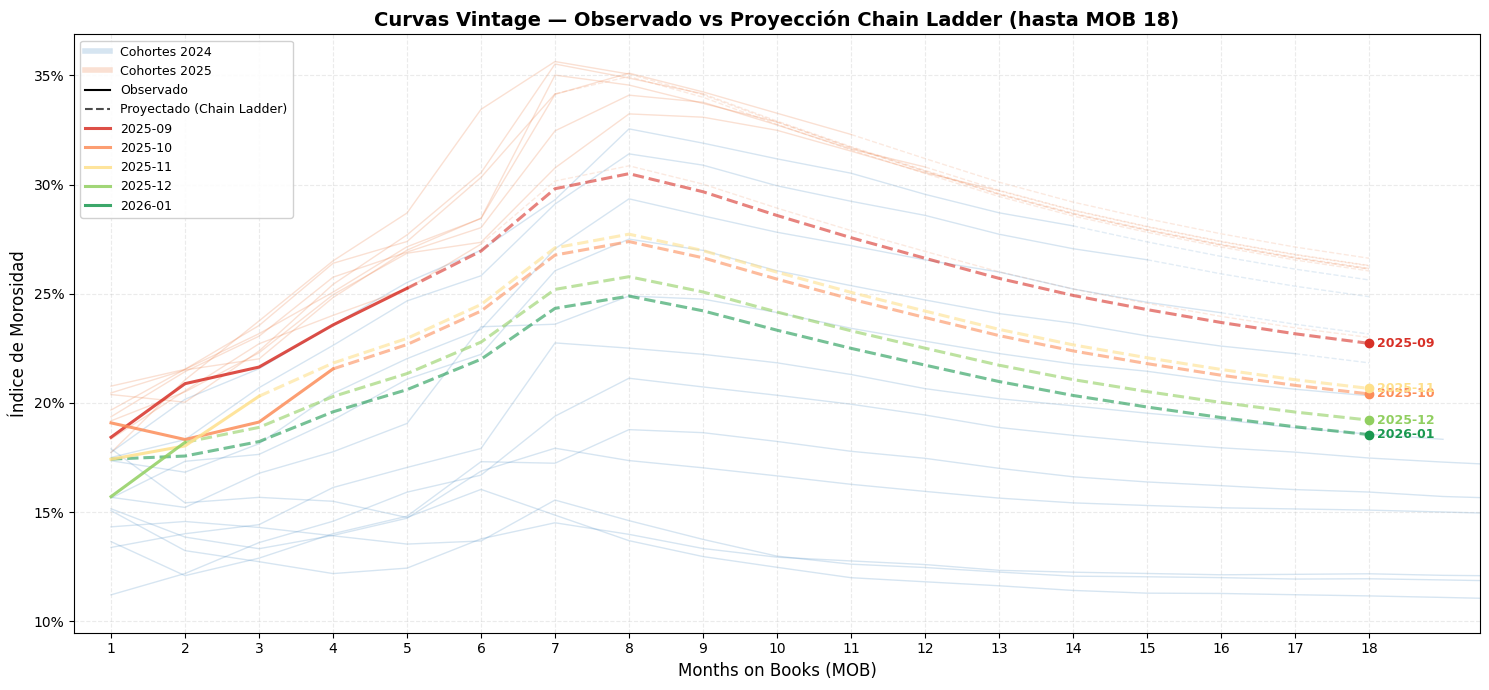

Gráfico guardado en reports/curvas_proyeccion_chainladder.png


In [21]:
LW_INDIVIDUAL = 1.0
LW_PROMEDIO = 2.8
LW_HIGHLIGHT = 2.2

COLORES_DESTACADAS = ["#d73027", "#fc8d59", "#fee08b", "#91cf60", "#1a9850"]

# Leer matrices
matriz_obs = pd.read_csv(os.path.join(PROCESSED_DIR, "matriz_vintage.csv"), sep=";", decimal=",", index_col=0)
matriz_proy = pd.read_csv(os.path.join(PROCESSED_DIR, "matriz_proyectada.csv"), sep=";", decimal=",", index_col=0)

cohortes_ordenadas = sorted(matriz_proy.index)
ultimas_n = cohortes_ordenadas[-N_DESTACAR:]
color_por_cohorte = {c: COLORES_DESTACADAS[i % len(COLORES_DESTACADAS)] for i, c in enumerate(ultimas_n)}

cohortes_2024 = [c for c in cohortes_ordenadas if c.startswith("2024")]
cohortes_2025 = [c for c in cohortes_ordenadas if c.startswith("2025")]
cohortes_2026 = [c for c in cohortes_ordenadas if c.startswith("2026")]

def extraer_obs(cohorte):
    vals = matriz_obs.loc[cohorte].dropna()
    mobs = [int(c.replace("MOB_", "")) for c in vals.index]
    return mobs, vals.values

def extraer_proy(cohorte):
    vals = matriz_proy.loc[cohorte].dropna()
    mobs = [int(c.replace("MOB_", "")) for c in vals.index]
    return mobs, vals.values

def parte_proyectada(cohorte):
    obs_mobs, _ = extraer_obs(cohorte)
    proy_mobs, proy_vals = extraer_proy(cohorte)
    ultimo_obs = max(obs_mobs)
    # Incluir el ultimo observado para continuidad
    mask = [m >= ultimo_obs for m in proy_mobs]
    mobs_out = [m for m, keep in zip(proy_mobs, mask) if keep]
    vals_out = [v for v, keep in zip(proy_vals, mask) if keep]
    return mobs_out, vals_out

fig, ax = plt.subplots(figsize=(15, 7))

def plot_cohortes(cohortes, color_base):
    for cohorte in cohortes:
        es_destacada = cohorte in ultimas_n
        color = color_por_cohorte[cohorte] if es_destacada else color_base
        alpha = ALPHA_HIGHLIGHT if es_destacada else ALPHA_INDIVIDUAL
        lw = LW_HIGHLIGHT if es_destacada else LW_INDIVIDUAL

        # Parte observada (solida)
        obs_m, obs_v = extraer_obs(cohorte)
        ax.plot(obs_m, obs_v, color=color, alpha=alpha, linewidth=lw, linestyle="-", zorder=3 if es_destacada else 1)

        # Parte proyectada (punteada)
        proy_m, proy_v = parte_proyectada(cohorte)
        if len(proy_m) > 1:  # solo si hay proyeccion
            ax.plot(proy_m, proy_v, color=color, alpha=alpha * 0.7, linewidth=lw, linestyle="--", zorder=2 if es_destacada else 0)

plot_cohortes(cohortes_2024, COLOR_2024)
plot_cohortes(cohortes_2025, COLOR_2025)
plot_cohortes(cohortes_2026, COLOR_2026)

# Anotaciones para destacadas
for cohorte in ultimas_n:
    proy_m, proy_v = extraer_proy(cohorte)
    color = color_por_cohorte[cohorte]
    ax.annotate(cohorte, xy=(proy_m[-1], proy_v[-1]),
                xytext=(6, 0), textcoords="offset points",
                fontsize=9, fontweight="bold", color=color, va="center", zorder=5)
    ax.plot(proy_m[-1], proy_v[-1], "o", color=color, markersize=6, zorder=5)

ax.set_xlabel("Months on Books (MOB)", fontsize=12)
ax.set_ylabel("Índice de Morosidad", fontsize=12)
ax.set_title(f"Curvas Vintage — Observado vs Proyección Chain Ladder (hasta MOB {MOB_OBJETIVO})",
             fontsize=14, fontweight="bold")
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals=0))
ax.set_xticks(range(1, MOB_OBJETIVO + 1))
ax.grid(True, alpha=0.25, linestyle="--")
ax.set_xlim(0.5, MOB_OBJETIVO + 1.5)

legend_elements = [
    Line2D([0], [0], color=COLOR_2024, alpha=ALPHA_INDIVIDUAL, lw=4, label="Cohortes 2024"),
    Line2D([0], [0], color=COLOR_2025, alpha=ALPHA_INDIVIDUAL, lw=4, label="Cohortes 2025"),
    Line2D([0], [0], color="black", lw=1.5, ls="-", label="Observado"),
    Line2D([0], [0], color="black", lw=1.5, ls="--", alpha=0.7, label="Proyectado (Chain Ladder)"),
]
for cohorte in ultimas_n:
    legend_elements.append(
        Line2D([0], [0], color=color_por_cohorte[cohorte], lw=LW_HIGHLIGHT, alpha=ALPHA_HIGHLIGHT, label=cohorte))

ax.legend(handles=legend_elements, loc="upper left", fontsize=9, framealpha=0.9)

plt.tight_layout()
plt.savefig(os.path.join(PROJECT_ROOT, "reports", "curvas_proyeccion_chainladder.png"), dpi=150, bbox_inches="tight")
plt.show()
print("Gráfico guardado en reports/curvas_proyeccion_chainladder.png")

---
## 5. Tabla de Mora Última (Ultimate)

Para cada cohorte: índice observado actual vs índice proyectado al MOB objetivo.
El **desarrollo restante** indica cuánto más se espera que crezca la mora.

In [22]:
matriz_obs = pd.read_csv(os.path.join(PROCESSED_DIR, "matriz_vintage.csv"), sep=";", decimal=",", index_col=0)
matriz_proy = pd.read_csv(os.path.join(PROCESSED_DIR, "matriz_proyectada.csv"), sep=";", decimal=",", index_col=0)

col_ultimate = f"MOB_{MOB_OBJETIVO}"

resumen = []
for cohorte in sorted(matriz_proy.index):
    obs = matriz_obs.loc[cohorte].dropna()
    ultimo_mob_obs = max(int(c.replace("MOB_", "")) for c in obs.index)
    indice_actual = obs.iloc[-1]
    indice_ultimate = matriz_proy.loc[cohorte, col_ultimate]
    desarrollo_restante = indice_ultimate - indice_actual
    mobs_proyectados = max(0, MOB_OBJETIVO - ultimo_mob_obs)

    resumen.append({
        "cohorte": cohorte,
        "mob_actual": ultimo_mob_obs,
        "indice_actual": indice_actual,
        f"ultimate_mob_{MOB_OBJETIVO}": indice_ultimate,
        "desarrollo_restante": desarrollo_restante,
        "mobs_proyectados": mobs_proyectados,
    })

df_resumen = pd.DataFrame(resumen).set_index("cohorte")

print(f"TABLA DE MORA ÚLTIMA (Ultimate al MOB {MOB_OBJETIVO})")
print("=" * 80)
print(f"{'Cohorte':>10s} | {'MOB obs':>7s} | {'Actual':>8s} | {'Ultimate':>8s} | {'Restante':>9s} | {'MOBs proy':>9s}")
print("-" * 80)
for _, row in df_resumen.iterrows():
    print(f"{row.name:>10s} | {int(row['mob_actual']):>7d} | {row['indice_actual']:>7.2%} | "
          f"{row[f'ultimate_mob_{MOB_OBJETIVO}']:>7.2%} | {row['desarrollo_restante']:>+8.2%} | "
          f"{int(row['mobs_proyectados']):>9d}")
print("=" * 80)

# Mostrar como tabla estilizada
df_resumen.style.format({
    "indice_actual": "{:.2%}",
    f"ultimate_mob_{MOB_OBJETIVO}": "{:.2%}",
    "desarrollo_restante": "{:+.2%}",
    "mob_actual": "{:.0f}",
    "mobs_proyectados": "{:.0f}",
}).background_gradient(subset=[f"ultimate_mob_{MOB_OBJETIVO}"], cmap="RdYlGn_r")

TABLA DE MORA ÚLTIMA (Ultimate al MOB 18)
   Cohorte | MOB obs |   Actual | Ultimate |  Restante | MOBs proy
--------------------------------------------------------------------------------
   2022-01 |      49 |   8.13% |  10.79% |   +2.65% |         0
   2022-02 |      48 |   7.80% |  10.46% |   +2.66% |         0
   2022-03 |      47 |   7.86% |  10.35% |   +2.49% |         0
   2022-04 |      46 |   7.81% |  10.40% |   +2.59% |         0
   2022-05 |      45 |   7.26% |   9.54% |   +2.28% |         0
   2022-06 |      44 |   7.35% |   9.51% |   +2.16% |         0
   2022-07 |      43 |   6.78% |   8.91% |   +2.13% |         0
   2022-08 |      42 |   6.26% |   7.95% |   +1.69% |         0
   2022-09 |      41 |   6.12% |   7.69% |   +1.57% |         0
   2022-10 |      40 |   5.81% |   7.59% |   +1.79% |         0
   2022-11 |      39 |   5.65% |   7.28% |   +1.63% |         0
   2022-12 |      38 |   5.97% |   7.31% |   +1.34% |         0
   2023-01 |      37 |   5.63% |   7.12% |

,mob_actual,indice_actual,ultimate_mob_18,desarrollo_restante,mobs_proyectados
cohorte,,,,,
2022-01,49,8.13%,10.79%,+2.65%,0
2022-02,48,7.80%,10.46%,+2.66%,0
2022-03,47,7.86%,10.35%,+2.49%,0
2022-04,46,7.81%,10.40%,+2.59%,0
2022-05,45,7.26%,9.54%,+2.28%,0
2022-06,44,7.35%,9.51%,+2.16%,0
2022-07,43,6.78%,8.91%,+2.13%,0
2022-08,42,6.26%,7.95%,+1.69%,0
2022-09,41,6.12%,7.69%,+1.57%,0


---
## 6. Comparación de Ultimates por Año

Distribución del índice de morosidad proyectado al MOB objetivo, agrupado por año de originación.

C:\Users\skannema\AppData\Local\Temp\ipykernel_12076\3869150804.py:38: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax2.boxplot([datos_por_anio[a] for a in anios], labels=anios, patch_artist=True, widths=0.5)


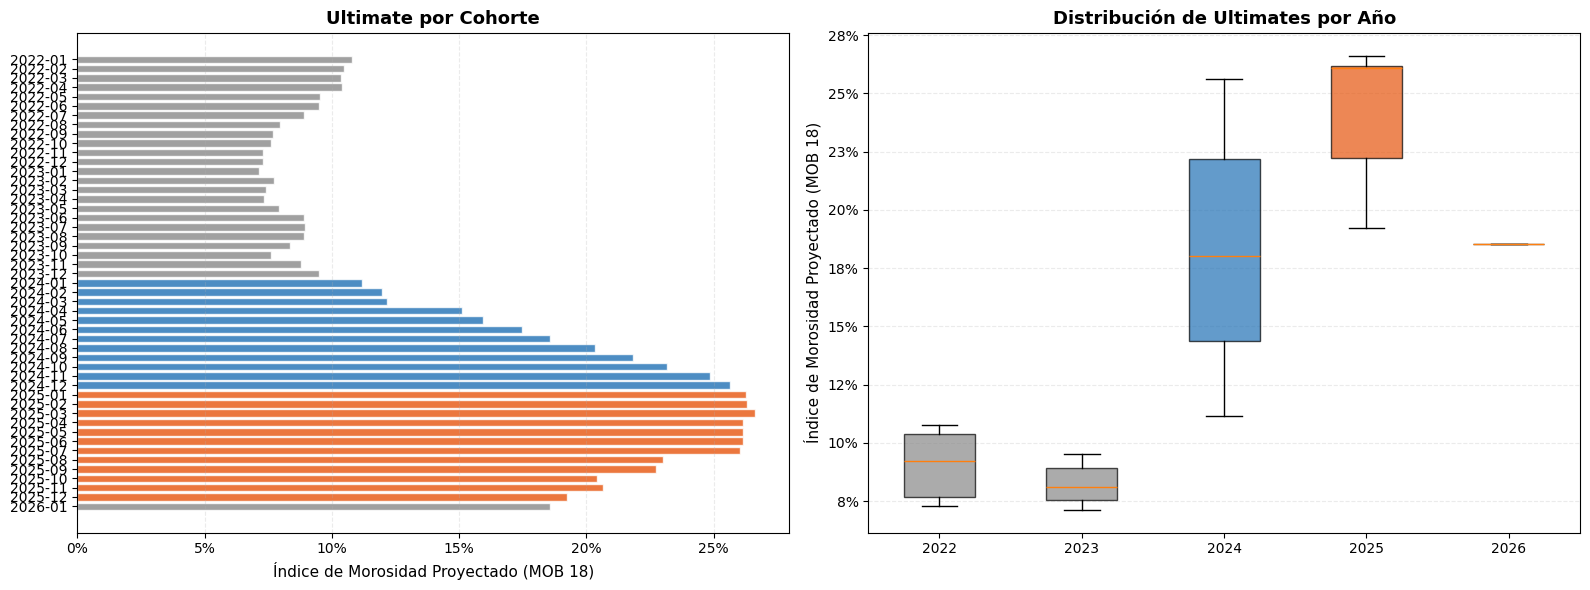


RESUMEN POR AÑO (Ultimate al MOB 18):
  2022: promedio=8.98%, min=7.28%, max=10.79%, n=12
  2023: promedio=8.21%, min=7.12%, max=9.50%, n=12
  2024: promedio=18.18%, min=11.17%, max=25.63%, n=12
  2025: promedio=24.14%, min=19.22%, max=26.63%, n=12
  2026: promedio=18.55%, min=18.55%, max=18.55%, n=1


In [23]:
col_ult = f"ultimate_mob_{MOB_OBJETIVO}"

# Agrupar por año
df_resumen["anio"] = df_resumen.index.str[:4]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# --- Panel izquierdo: barras por cohorte ---
colores_barra = []
for c in df_resumen.index:
    if c.startswith("2024"):
        colores_barra.append(COLOR_2024)
    elif c.startswith("2025"):
        colores_barra.append(COLOR_2025)
    else:
        colores_barra.append(COLOR_2026)

ax1.barh(df_resumen.index, df_resumen[col_ult], color=colores_barra, alpha=0.8, edgecolor="white")
ax1.set_xlabel(f"Índice de Morosidad Proyectado (MOB {MOB_OBJETIVO})", fontsize=11)
ax1.set_title("Ultimate por Cohorte", fontsize=13, fontweight="bold")
ax1.xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals=0))
ax1.grid(True, alpha=0.25, linestyle="--", axis="x")
ax1.invert_yaxis()

# --- Panel derecho: box plot por año ---
datos_por_anio = {}
colores_box = {}
for anio, grupo in df_resumen.groupby("anio"):
    datos_por_anio[anio] = grupo[col_ult].values
    if anio == "2024":
        colores_box[anio] = COLOR_2024
    elif anio == "2025":
        colores_box[anio] = COLOR_2025
    else:
        colores_box[anio] = COLOR_2026

anios = sorted(datos_por_anio.keys())
bp = ax2.boxplot([datos_por_anio[a] for a in anios], labels=anios, patch_artist=True, widths=0.5)
for patch, anio in zip(bp["boxes"], anios):
    patch.set_facecolor(colores_box[anio])
    patch.set_alpha(0.7)

ax2.set_ylabel(f"Índice de Morosidad Proyectado (MOB {MOB_OBJETIVO})", fontsize=11)
ax2.set_title("Distribución de Ultimates por Año", fontsize=13, fontweight="bold")
ax2.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals=0))
ax2.grid(True, alpha=0.25, linestyle="--", axis="y")

plt.tight_layout()
plt.savefig(os.path.join(PROJECT_ROOT, "reports", "comparacion_ultimates.png"), dpi=150, bbox_inches="tight")
plt.show()

# Resumen numérico
print(f"\nRESUMEN POR AÑO (Ultimate al MOB {MOB_OBJETIVO}):")
print("=" * 50)
for anio in anios:
    vals = datos_por_anio[anio]
    print(f"  {anio}: promedio={np.mean(vals):.2%}, min={np.min(vals):.2%}, max={np.max(vals):.2%}, n={len(vals)}")
print("=" * 50)

---
## 7. Resumen Ejecutivo

In [24]:
factores_cl = pd.read_csv(os.path.join(PROCESSED_DIR, "factores_chainladder.csv"), sep=";", decimal=",")
col_ult = f"ultimate_mob_{MOB_OBJETIVO}"

print("=" * 60)
print(f"RESUMEN EJECUTIVO - PROYECCIÓN CHAIN LADDER (MOB {MOB_OBJETIVO})")
print("=" * 60)

# Factor acumulado
factor_acum = 1.0
for col in factores_cl.columns:
    factor_acum *= factores_cl[col].iloc[0]
print(f"\nFactor de desarrollo acumulado (MOB 1 -> MOB {MOB_OBJETIVO}): {factor_acum:.4f}")
print(f"  Esto significa que un índice en MOB 1 se multiplica por {factor_acum:.2f}x hasta MOB {MOB_OBJETIVO}")

# Transición con mayor factor
max_trans = factores_cl.iloc[0].idxmax()
max_val = factores_cl.iloc[0].max()
print(f"\nTransición con mayor crecimiento: {max_trans} (factor {max_val:.4f})")

# Transiciones con factor < 1
factores_bajo_1 = [(col, factores_cl[col].iloc[0]) for col in factores_cl.columns if factores_cl[col].iloc[0] < 1]
if factores_bajo_1:
    print(f"\nTransiciones donde la mora baja:")
    for trans, val in factores_bajo_1:
        print(f"  {trans}: {val:.4f}")
else:
    print(f"\nNinguna transición muestra caída de mora (todos los factores >= 1)")

# Ultimates por año
print('\n' + '-' * 60)
print(f"\nUltimates proyectados (MOB {MOB_OBJETIVO}):")
for anio in sorted(df_resumen["anio"].unique()):
    grupo = df_resumen[df_resumen["anio"] == anio]
    print(f"\n  Año {anio} ({len(grupo)} cohortes):")
    print(f"    Promedio:  {grupo[col_ult].mean():.2%}")
    print(f"    Mínimo:   {grupo[col_ult].min():.2%} ({grupo[col_ult].idxmin()})")
    print(f"    Máximo:   {grupo[col_ult].max():.2%} ({grupo[col_ult].idxmax()})")

# Top 5 cohortes
print('\n' + '-' * 60)
top5 = df_resumen.nlargest(5, col_ult)
print(f"\nTop 5 cohortes con mayor mora proyectada al MOB {MOB_OBJETIVO}:")
for _, row in top5.iterrows():
    print(f"  {row.name}: {row[col_ult]:.2%} (observado hasta MOB {int(row['mob_actual'])}, {int(row['mobs_proyectados'])} MOBs proyectados)")

print("\n" + "=" * 60)

RESUMEN EJECUTIVO - PROYECCIÓN CHAIN LADDER (MOB 18)

Factor de desarrollo acumulado (MOB 1 -> MOB 18): 1.0645
  Esto significa que un índice en MOB 1 se multiplica por 1.06x hasta MOB 18

Transición con mayor crecimiento: 6->7 (factor 1.1059)

Transiciones donde la mora baja:
  8->9: 0.9729
  9->10: 0.9634
  10->11: 0.9644
  11->12: 0.9658
  12->13: 0.9654
  13->14: 0.9696
  14->15: 0.9740
  15->16: 0.9757
  16->17: 0.9781
  17->18: 0.9811

------------------------------------------------------------

Ultimates proyectados (MOB 18):

  Año 2022 (12 cohortes):
    Promedio:  8.98%
    Mínimo:   7.28% (2022-11)
    Máximo:   10.79% (2022-01)

  Año 2023 (12 cohortes):
    Promedio:  8.21%
    Mínimo:   7.12% (2023-01)
    Máximo:   9.50% (2023-12)

  Año 2024 (12 cohortes):
    Promedio:  18.18%
    Mínimo:   11.17% (2024-01)
    Máximo:   25.63% (2024-12)

  Año 2025 (12 cohortes):
    Promedio:  24.14%
    Mínimo:   19.22% (2025-12)
    Máximo:   26.63% (2025-03)

  Año 2026 (1 cohort